In [ ]:
!pip install matplotlib scipy

In [1]:
import json
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import t

In [8]:
normal_experiment_constraints_file = 'zk_cred_logic/experiments/constraints.csv'
streaming_experiment_constraints_file = 'zk_cred_streaming_logic/experiments/constraints.csv'
normal_constraints_df = pd.read_csv(normal_experiment_constraints_file).reset_index(drop=True)
streaming_constraints_df = pd.read_csv(streaming_experiment_constraints_file).reset_index(drop=True)
constraints_df = pd.concat([normal_constraints_df, streaming_constraints_df, pd.DataFrame([{'k': 'cold_start', 'constraints': 1526683}])])

constraints_df['Constraints'] = constraints_df['constraints'].apply(lambda x: f"{x:,}")
constraints_df['History Size / Circuit Type'] = constraints_df['k'].apply(lambda x: 'Cold Start' if x == 'cold_start' else 'Streaming' if x == 'streaming' else f"{x:,}")

print(constraints_df[['History Size / Circuit Type', 'Constraints']].to_latex(index=False))

\begin{tabular}{ll}
\toprule
History Size / Circuit Type & Constraints \\
\midrule
1 & 30,317 \\
5 & 35,165 \\
10 & 35,995 \\
25 & 46,853 \\
50 & 67,739 \\
100 & 101,143 \\
250 & 209,723 \\
500 & 393,479 \\
1,000 & 752,623 \\
2,500 & 1,838,423 \\
5,000 & 3,650,879 \\
Streaming & 26,187 \\
Cold Start & 1,526,683 \\
\bottomrule
\end{tabular}



In [3]:
def load_results(path):
    with open(path, 'r') as f:
        data = json.load(f)
    data = [d for d in data if d.get('proveError') is None and d.get('verifyError') is None]
    prove = np.array([d['proveTimeMs'] for d in data])
    verify = np.array([d['verifyTimeMs'] for d in data])
    return prove, verify

def mean_ci(arr):
    n = len(arr)
    mean = np.mean(arr)
    stderr = np.std(arr, ddof=1) / np.sqrt(n)
    ci = t.ppf(0.975, n-1) * stderr
    return mean, ci

def get_k_from_filename(fname):
    return int(fname.split('_k')[-1].split('.')[0])

def aggregate_results(result_dir):
    files = sorted(glob(f"{result_dir}/experiment_results*k*.json"), key=get_k_from_filename)
    ks, means, cis, means_verify, cis_verify = [], [], [], [], []
    for f in files:
        k = get_k_from_filename(f)
        prove, verify = load_results(f)
        m, ci = mean_ci(prove)
        m_v, ci_v = mean_ci(verify)
        ks.append(k)
        means.append(m)
        cis.append(ci)
        means_verify.append(m_v)
        cis_verify.append(ci_v)
    return np.array(ks), np.array(means), np.array(cis), np.array(means_verify), np.array(cis_verify)

def load_streaming(result_dir):
    prove, verify = load_results(f"{result_dir}/experiment_results_streaming.json")
    m, ci = mean_ci(prove)
    m_v, ci_v = mean_ci(verify)
    return m, ci, m_v, ci_v

def load_cold_start(result_dir):
    prove, verify = load_results(f"{result_dir}/experiment_results_cold_start.json")
    m, ci = mean_ci(prove)
    m_v, ci_v = mean_ci(verify)
    return m, ci, m_v, ci_v

[<ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>, <ErrorbarContainer object of 3 artists>, <matplotlib.lines.Line2D object at 0x1158b2c80>]
['Credential history', 'Single attribution', 'Multi attribution', 'Streaming']


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_52179/2476026935.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # use full width since legend is inside


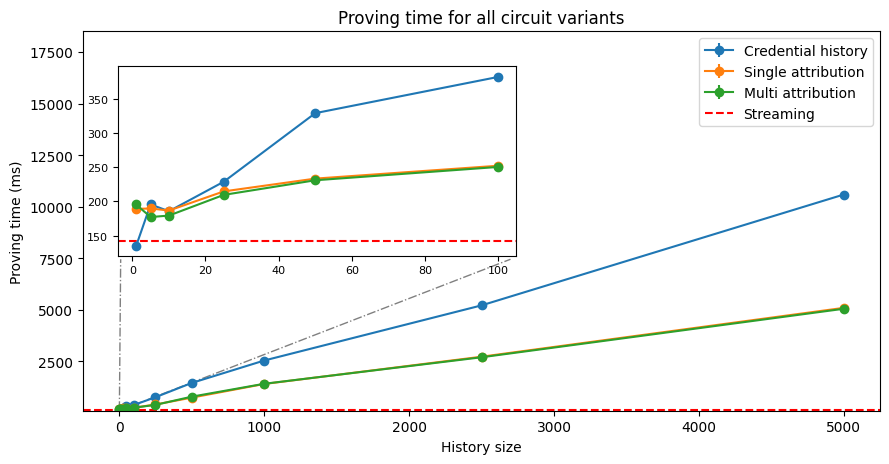

In [12]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ks, means, cis, means_verify, cis_verify = aggregate_results("results")
ks_chain, means_chain, cis_chain, means_chain_verify, cis_chain_verify = aggregate_results("results_attribution_chain") 
ks_single, means_single, cis_single, means_single_verify, cis_single_verify = aggregate_results("results_attribution_single") 
# Streaming
m_stream_ldp, ci_stream_ldp, m_stream_verify, ci_stream_verify = load_streaming("results")
#Cold start
m_cold_start, ci_cold_start, m_cold_start_verify, ci_cold_start_verify = load_cold_start("results")

fig, ax_main = plt.subplots(1, 1, figsize=(9, 5))

# Main plot: all four time series
main_lines = []
main_lines += ax_main.errorbar(ks, means, yerr=cis, fmt='-o', label='Credential history').lines
main_lines += ax_main.errorbar(ks_single, means_single, yerr=cis_single, fmt='-o', label='Single attribution').lines
main_lines += ax_main.errorbar(ks_chain, means_chain, yerr=cis_chain, fmt='-o', label='Multi attribution').lines

ax_main.set_xlabel('History size')
ax_main.set_ylabel('Proving time (ms)')
ax_main.set_ylim(0, 18500)
ax_main.set_title('Proving time for all circuit variants')
# y_min = np.min(means - cis)
y_min = min(np.min(means - cis), np.min(means_chain - cis_chain), np.min(means_single - cis_single))
ax_main.set_ylim(bottom=y_min * 0.8)
streaming_line = ax_main.axhline(m_stream_ldp, color='red', linestyle='--', label='Streaming')
# cold_start_line = ax_main.axhline(m_cold_start, color='blue', linestyle='--', label='Cold start')

ax_main.yaxis.tick_left()
ax_main.tick_params(labelright=False)

# Inset: zoom in on small history sizes, top left
ax_inset = inset_axes(ax_main, width="50%", height="50%", loc='upper left', borderpad=2.5)
mask = (ks <= 100)
mask_chain = (ks_chain <= 100)
mask_single = (ks_single <= 100)
ax_inset.errorbar(ks[mask], means[mask], yerr=cis[mask], fmt='-o')
ax_inset.errorbar(ks_single[mask_single], means_single[mask_single], yerr=cis_single[mask_single], fmt='-o')
ax_inset.errorbar(ks_chain[mask_chain], means_chain[mask_chain], yerr=cis_chain[mask_chain], fmt='-o')
ax_inset.axhline(m_stream_ldp, color='red', linestyle='--', label='Streaming')
ax_inset.tick_params(axis='both', which='major', labelsize=8)

# Coordinates for the region in the main plot (in data coordinates)
x1, x2 = min(ks[mask]), max(ks[mask])
y1, y2 = min(means[mask]), max(means[mask])

# Lower left
xy_main1 = (x1, means[mask][0])
xy_inset1 = (x1, means[mask][0])
# Upper right
xy_main2 = (x2, means[mask][-1])
xy_inset2 = (x2, means[mask][-1])

ax_main.plot([x1, 10], [y1, 7450], color='gray', linestyle='-.', linewidth=1)
ax_main.plot([x2, 2700], [y2, 7450], color='gray', linestyle='-.', linewidth=1)

# Legend inside the main plot, top right
handles, labels = ax_main.get_legend_handles_labels()

# Desired legend order: credential history, single attribution, multi attribution, streaming
desired_order = ['Credential history', 'Single attribution', 'Multi attribution', 'Streaming']
# Build a mapping from label to handle
label_to_handle = dict(zip(labels, handles))
# Reorder handles and labels
ordered_handles = [label_to_handle[label] for label in desired_order if label in label_to_handle]
ordered_labels = [label for label in desired_order if label in label_to_handle]

print(ordered_handles)
print(ordered_labels)

ax_main.legend(ordered_handles, ordered_labels, loc='upper right', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # use full width since legend is inside
plt.savefig("graphics/proving_v4.pdf", bbox_inches='tight')
plt.show()

In [13]:
m_cold_start, ci_cold_start, m_cold_start_verify, ci_cold_start_verify

(np.float64(3358.188765959551),
 np.float64(13.485830316105025),
 np.float64(15.985487464608418),
 np.float64(0.13547380122209937))

In [5]:
means

array([  134.25825653,   195.62434006,   185.64744246,   228.85789348,
         329.12201789,   382.12716419,   761.11488008,  1451.75337193,
        2539.58391076,  5213.42896182, 10587.99043365])

In [6]:
means_chain

array([ 195.55576352,  177.17555888,  179.29077219,  209.59409281,
        230.95952154,  250.45987684,  389.7329827 ,  787.0187466 ,
       1412.18776428, 2698.0274976 , 5049.37012939])

In [7]:
means_single

array([ 189.078012  ,  189.70944643,  186.68707039,  214.68754171,
        233.36933079,  252.19623275,  408.5335515 ,  740.40091081,
       1402.65191031, 2724.78587633, 5093.96996768])

In [8]:
m_stream_ldp, ci_stream_ldp

(np.float64(141.92447860000001), np.float64(0.9970401049525418))

In [13]:
means_verify

array([15.13709752, 15.95058313, 15.76209004, 15.91302172, 16.96790849,
       17.03214826, 17.12103491, 19.37656921, 20.1853457 , 19.9943994 ,
       22.02217211])

In [14]:
means_chain_verify

array([18.28358532, 18.393674  , 17.91799753, 18.31334822, 18.0172756 ,
       18.319599  , 18.55865171, 19.87331798, 22.03729629, 22.26394932,
       21.93074629])

In [15]:
means_single_verify

array([18.28358532, 18.6253211 , 18.28577154, 19.3476001 , 18.21293046,
       19.28032899, 19.30272073, 19.18738423, 22.06028035, 24.04770921,
       26.54411365])

In [12]:
m_stream_verify

np.float64(15.796499455445545)

In [45]:
serverside_timing_df = pd.read_csv('results/serverside_timing_results.csv')

serverside_timing_df['verification_ms'] = serverside_timing_df['verification_ns'] / 1e6
serverside_timing_df['nullifier_ms'] = serverside_timing_df['nullifier_ns'] / 1e6
serverside_timing_df['signing_ms'] = serverside_timing_df['signing_ns'] / 1e6
serverside_timing_df['total_ms'] = serverside_timing_df['total_ns'] / 1e6
serverside_timing_df.drop(columns=['trial', 'verification_ns', 'nullifier_ns', 'signing_ns', 'total_ns'], inplace=True)
serverside_timing_df.describe()



,verification_ms,nullifier_ms,signing_ms,total_ms
count,200.000000,200.000000,200.000000,200.000000
mean,6.018575,0.007864,0.125177,6.268263
std,0.558385,0.002967,0.040817,0.846136
min,5.096709,0.005446,0.095026,5.249270
25%,5.776354,0.006823,0.111079,5.968018
50%,6.131209,0.007425,0.117725,6.338301
75%,6.261626,0.008113,0.125767,6.486012
max,10.320449,0.041772,0.578463,14.794500


## Rebuttal / geohash analysis

In [1]:
import pandas as pd
import geohash2
from fixed_point_trig import haversine_distance

In [25]:
gowalla_df = pd.read_csv('/Users/haltriedman/Downloads/loc-gowalla_totalCheckins.txt', sep='\t', header=None, names=['user_id', 'ts', 'lat', 'long', 'loc_id'])
brightkite_df = pd.read_csv('/Users/haltriedman/Downloads/loc-brightkite_totalCheckins.txt', sep='\t', header=None, names=['user_id', 'ts', 'lat', 'long', 'loc_id'])

In [26]:
gowalla_df['user_id'] = gowalla_df['user_id'].astype(str) + '_gowalla' 
brightkite_df['user_id'] = brightkite_df['user_id'].astype(str) + '_brightkite' 
df = pd.concat([gowalla_df, brightkite_df])

In [27]:
df = df[['user_id', 'ts', 'lat', 'long']]

In [28]:
avg_checkin_loc_df = df.groupby(['user_id']).agg({'lat': 'mean', 'long': 'mean'}).reset_index()

In [29]:
df = pd.merge(df, avg_checkin_loc_df, on='user_id', suffixes=('', '_avg'))

In [31]:
df['geohash_current'] = df.apply(lambda row: geohash2.encode(row['lat'], row['long']), axis=1)
df['geohash_avg'] = df.apply(lambda row: geohash2.encode(row['lat_avg'], row['long_avg']), axis=1)

In [37]:
df.to_csv('location.csv', index=False)

In [2]:
df = pd.read_csv('location.csv')

In [3]:
def geohash_to_bits(geohash_str):
    """Convert geohash string to binary representation"""
    base32 = "0123456789bcdefghjkmnpqrstuvwxyz"
    bits = []
    for char in geohash_str:
        val = base32.index(char.lower())
        bits.extend([int(b) for b in format(val, '05b')])
    return bits

def bits_to_geohash(bits):
    """Convert binary representation to geohash string"""
    base32 = "0123456789bcdefghjkmnpqrstuvwxyz"
    geohash = ""
    for i in range(0, len(bits), 5):
        chunk = bits[i:i+5]
        if len(chunk) < 5:
            chunk = chunk + [0] * (5 - len(chunk))
        val = sum(chunk[j] * (2 ** (4 - j)) for j in range(5))
        geohash += base32[val]
    return geohash

def geohash_prefix_match(gh1, gh2, n_bits):
    """Check if two geohashes match in the first n_bits"""
    bits1 = geohash_to_bits(gh1)
    bits2 = geohash_to_bits(gh2)
    # Pad to same length
    max_len = max(len(bits1), len(bits2))
    bits1 = bits1 + [0] * (max_len - len(bits1))
    bits2 = bits2 + [0] * (max_len - len(bits2))
    # Check first n_bits
    return bits1[:n_bits] == bits2[:n_bits]

def haversine_standard(lat1, lon1, lat2, lon2, radius_km=6371.0):
    """Standard haversine distance using math library (ground truth)"""
    import math
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = (math.sin(dlat / 2) ** 2 + 
         math.cos(lat1_rad) * math.cos(lat2_rad) * 
         math.sin(dlon / 2) ** 2)
    c = 2 * math.asin(math.sqrt(a))
    
    return radius_km * c

def compare_methods(df, distance_threshold_km, n_bits_list):
    """
    Compare haversine distance (fixed-point and standard) vs geohash prefix matching for bounding box checks
    
    Args:
        df: DataFrame with columns lat, long, lat_avg, long_avg, geohash_current, geohash_avg
        distance_threshold_km: Distance threshold in km for haversine method
        n_bits_list: List of n-bit precisions to test for geohash method
    
    Returns:
        Dictionary with error rates for each method
    """
    results = {}
    
    # Standard haversine distance (ground truth using math library)
    df['haversine_standard_km'] = df.apply(
        lambda row: haversine_standard(row['lat'], row['long'], row['lat_avg'], row['long_avg']), 
        axis=1
    )
    df['within_haversine_standard'] = df['haversine_standard_km'] <= distance_threshold_km
    
    # Fixed-point haversine distance
    df['haversine_fixed_km'] = df.apply(
        lambda row: haversine_distance(row['lat'], row['long'], row['lat_avg'], row['long_avg']), 
        axis=1
    )
    df['within_haversine_fixed'] = df['haversine_fixed_km'] <= distance_threshold_km
    
    # Calculate error between fixed-point and standard haversine
    df['haversine_error_km'] = abs(df['haversine_fixed_km'] - df['haversine_standard_km'])
    df['haversine_relative_error'] = df['haversine_error_km'] / df['haversine_standard_km'].clip(lower=0.001)  # Avoid division by zero
    
    # Use standard haversine as ground truth
    ground_truth = df['within_haversine_standard']
    
    # Compare fixed-point haversine vs standard haversine
    false_positives_fixed = ((df['within_haversine_fixed'] == True) & (ground_truth == False)).sum()
    false_negatives_fixed = ((df['within_haversine_fixed'] == False) & (ground_truth == True)).sum()
    true_positives_fixed = ((df['within_haversine_fixed'] == True) & (ground_truth == True)).sum()
    true_negatives_fixed = ((df['within_haversine_fixed'] == False) & (ground_truth == False)).sum()
    
    total = len(df)
    results['fixed_point_haversine'] = {
        'false_positive_rate': false_positives_fixed / total,
        'false_negative_rate': false_negatives_fixed / total,
        'accuracy': (true_positives_fixed + true_negatives_fixed) / total,
        'precision': true_positives_fixed / (true_positives_fixed + false_positives_fixed) if (true_positives_fixed + false_positives_fixed) > 0 else 0,
        'recall': true_positives_fixed / (true_positives_fixed + false_negatives_fixed) if (true_positives_fixed + false_negatives_fixed) > 0 else 0,
        'false_positives': false_positives_fixed,
        'false_negatives': false_negatives_fixed,
        'true_positives': true_positives_fixed,
        'true_negatives': true_negatives_fixed,
        'mean_absolute_error_km': df['haversine_error_km'].mean(),
        'mean_relative_error': df['haversine_relative_error'].mean(),
        'max_error_km': df['haversine_error_km'].max(),
        'total': total
    }
    
    # Geohash method for different bit precisions
    for n_bits in n_bits_list:
        col_name = f'within_geohash_{n_bits}bits'
        df[col_name] = df.apply(
            lambda row: geohash_prefix_match(row['geohash_current'], row['geohash_avg'], n_bits),
            axis=1
        )
        
        # Calculate error rates vs standard haversine (ground truth)
        false_positives = ((df[col_name] == True) & (ground_truth == False)).sum()
        false_negatives = ((df[col_name] == False) & (ground_truth == True)).sum()
        true_positives = ((df[col_name] == True) & (ground_truth == True)).sum()
        true_negatives = ((df[col_name] == False) & (ground_truth == False)).sum()
        
        false_positive_rate = false_positives / total
        false_negative_rate = false_negatives / total
        accuracy = (true_positives + true_negatives) / total
        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        
        results[n_bits] = {
            'false_positive_rate': false_positive_rate,
            'false_negative_rate': false_negative_rate,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'false_positives': false_positives,
            'false_negatives': false_negatives,
            'true_positives': true_positives,
            'true_negatives': true_negatives,
            'total': total
        }
    
    return results, df

# Test with different distance thresholds and geohash precisions
distance_thresholds_km = [0.5, 1.0, 2.0, 5.0, 10.0]
n_bits_list = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

print("Comparing Haversine distance vs N-bit geohash for bounding box checks")
print("=" * 80)


Comparing Haversine distance vs N-bit geohash for bounding box checks


In [ ]:
# Run comparison for each distance threshold
all_results = {}

for threshold_km in distance_thresholds_km:
    print(f"\nDistance threshold: {threshold_km} km")
    print("=" * 100)
    
    results, df_with_results = compare_methods(df.copy(), threshold_km, n_bits_list)
    all_results[threshold_km] = results
    
    # Print fixed-point haversine comparison
    fp_hav = results['fixed_point_haversine']
    print(f"\nFixed-Point Haversine vs Standard Haversine:")
    print(f"  False Positive Rate: {fp_hav['false_positive_rate']:.6f}")
    print(f"  False Negative Rate: {fp_hav['false_negative_rate']:.6f}")
    print(f"  Accuracy: {fp_hav['accuracy']:.6f}")
    print(f"  Precision: {fp_hav['precision']:.6f}")
    print(f"  Recall: {fp_hav['recall']:.6f}")
    print(f"  Mean Absolute Error: {fp_hav['mean_absolute_error_km']:.6f} km")
    print(f"  Mean Relative Error: {fp_hav['mean_relative_error']:.6f}")
    print(f"  Max Error: {fp_hav['max_error_km']:.6f} km")
    
    # Print geohash summary table
    print(f"\nGeohash N-bit Precision Comparison:")
    print(f"{'N-bits':<10} {'False Pos Rate':<18} {'False Neg Rate':<18} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")
    print("-" * 100)
    for n_bits in sorted(n_bits_list):
        r = results[n_bits]
        print(f"{n_bits:<10} {r['false_positive_rate']:<18.6f} {r['false_negative_rate']:<18.6f} "
              f"{r['accuracy']:<12.6f} {r['precision']:<12.6f} {r['recall']:<12.6f}")
    
    # Find best n_bits for this threshold (lowest combined error rate)
    best_n_bits = min(n_bits_list, key=lambda n: results[n]['false_positive_rate'] + results[n]['false_negative_rate'])
    best_error = results[best_n_bits]['false_positive_rate'] + results[best_n_bits]['false_negative_rate']
    print(f"\nBest n_bits for {threshold_km}km threshold: {best_n_bits} bits (total error rate: {best_error:.6f})")


Distance threshold: 0.5 km

Fixed-Point Haversine vs Standard Haversine:
  False Positive Rate: 0.007420
  False Negative Rate: 0.000003
  Accuracy: 0.992577
  Precision: 0.887233
  Recall: 0.999951
  Mean Absolute Error: 42.473728 km
  Mean Relative Error: 0.016945
  Max Error: 16631.279151 km

Geohash N-bit Precision Comparison:
N-bits     False Pos Rate     False Neg Rate     Accuracy     Precision    Recall      
----------------------------------------------------------------------------------------------------
5          0.829278           0.000000           0.170722     0.065769     0.999998    
10         0.668598           0.000001           0.331402     0.080304     0.999991    
15         0.383743           0.000014           0.616243     0.132017     0.999761    
20         0.158926           0.000115           0.840959     0.268266     0.998025    
25         0.035228           0.000828           0.963944     0.620304     0.985813    
30         0.001165           0.00504

In [14]:
df_with_results.to_csv('location_with_results.csv')

In [18]:
import pandas as pd

df_with_results = pd.read_csv('location_with_results.csv')

In [ ]:
df_with_results = df_with_results[
    (df_with_results['geohash_current'] != '7zzzzzzzzzzz') & # remove (0,0) coordinates
    (df_with_results['lat'].isna() == False) & # remove rows with no latitude
    (df_with_results['long'].isna() == False) # remove rows with no longitude
]

In [22]:
df_with_results.sort_values('haversine_error_km', ascending=False)

,Unnamed: 0,user_id,ts,lat,long,lat_avg,long_avg,geohash_current,geohash_avg,haversine_standard_km,...,within_geohash_5bits,within_geohash_10bits,within_geohash_15bits,within_geohash_20bits,within_geohash_25bits,within_geohash_30bits,within_geohash_35bits,within_geohash_40bits,within_geohash_45bits,within_geohash_50bits
9638031,9638031,13810_brightkite,2009-08-07T04:21:00Z,20.750278,-156.500278,-0.102467,-0.390041,8e8wn9rzphnv,7zzxrj7gp6sr,16549.313750,...,False,False,False,False,False,False,False,False,False,False
9638033,9638033,13810_brightkite,2009-07-12T06:01:47Z,-41.278536,174.776639,-0.102467,-0.390041,rbsm1jkrng5t,7zzxrj7gp6sr,15388.033161,...,False,False,False,False,False,False,False,False,False,False
9638032,9638032,13810_brightkite,2009-08-07T04:18:42Z,-42.000000,174.000000,-0.102467,-0.390041,rbe9p6numbe9,7zzxrj7gp6sr,15299.782181,...,False,False,False,False,False,False,False,False,False,False
2810636,2810636,33693_gowalla,2010-06-13T05:28:57Z,0.045248,32.443797,33.194354,-93.472849,s8p0620ze6b3,9vvsbfz5hspb,13273.367545,...,False,False,False,False,False,False,False,False,False,False
9638029,9638029,13810_brightkite,2009-08-07T04:27:16Z,37.774929,-122.419415,-0.102467,-0.390041,9q8yyk8yuvhh,7zzxrj7gp6sr,12771.121801,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10560768,10560768,30555_brightkite,2008-05-02T01:20:53Z,51.021111,-3.104722,51.021111,-3.104722,gcjf3255w8rq,gcjf3255w8rq,0.000000,...,True,True,True,True,True,True,True,True,True,True
9400310,9400310,13102_brightkite,2010-09-29T15:27:04Z,39.760000,-98.500000,39.760000,-98.500000,9z1fnw46z9hw,9z1fnw46z9hw,0.000000,...,True,True,True,True,True,True,True,True,True,True
9400309,9400309,13102_brightkite,2010-09-29T15:41:26Z,39.760000,-98.500000,39.760000,-98.500000,9z1fnw46z9hw,9z1fnw46z9hw,0.000000,...,True,True,True,True,True,True,True,True,True,True
9400308,9400308,13102_brightkite,2010-09-29T15:47:39Z,39.760000,-98.500000,39.760000,-98.500000,9z1fnw46z9hw,9z1fnw46z9hw,0.000000,...,True,True,True,True,True,True,True,True,True,True


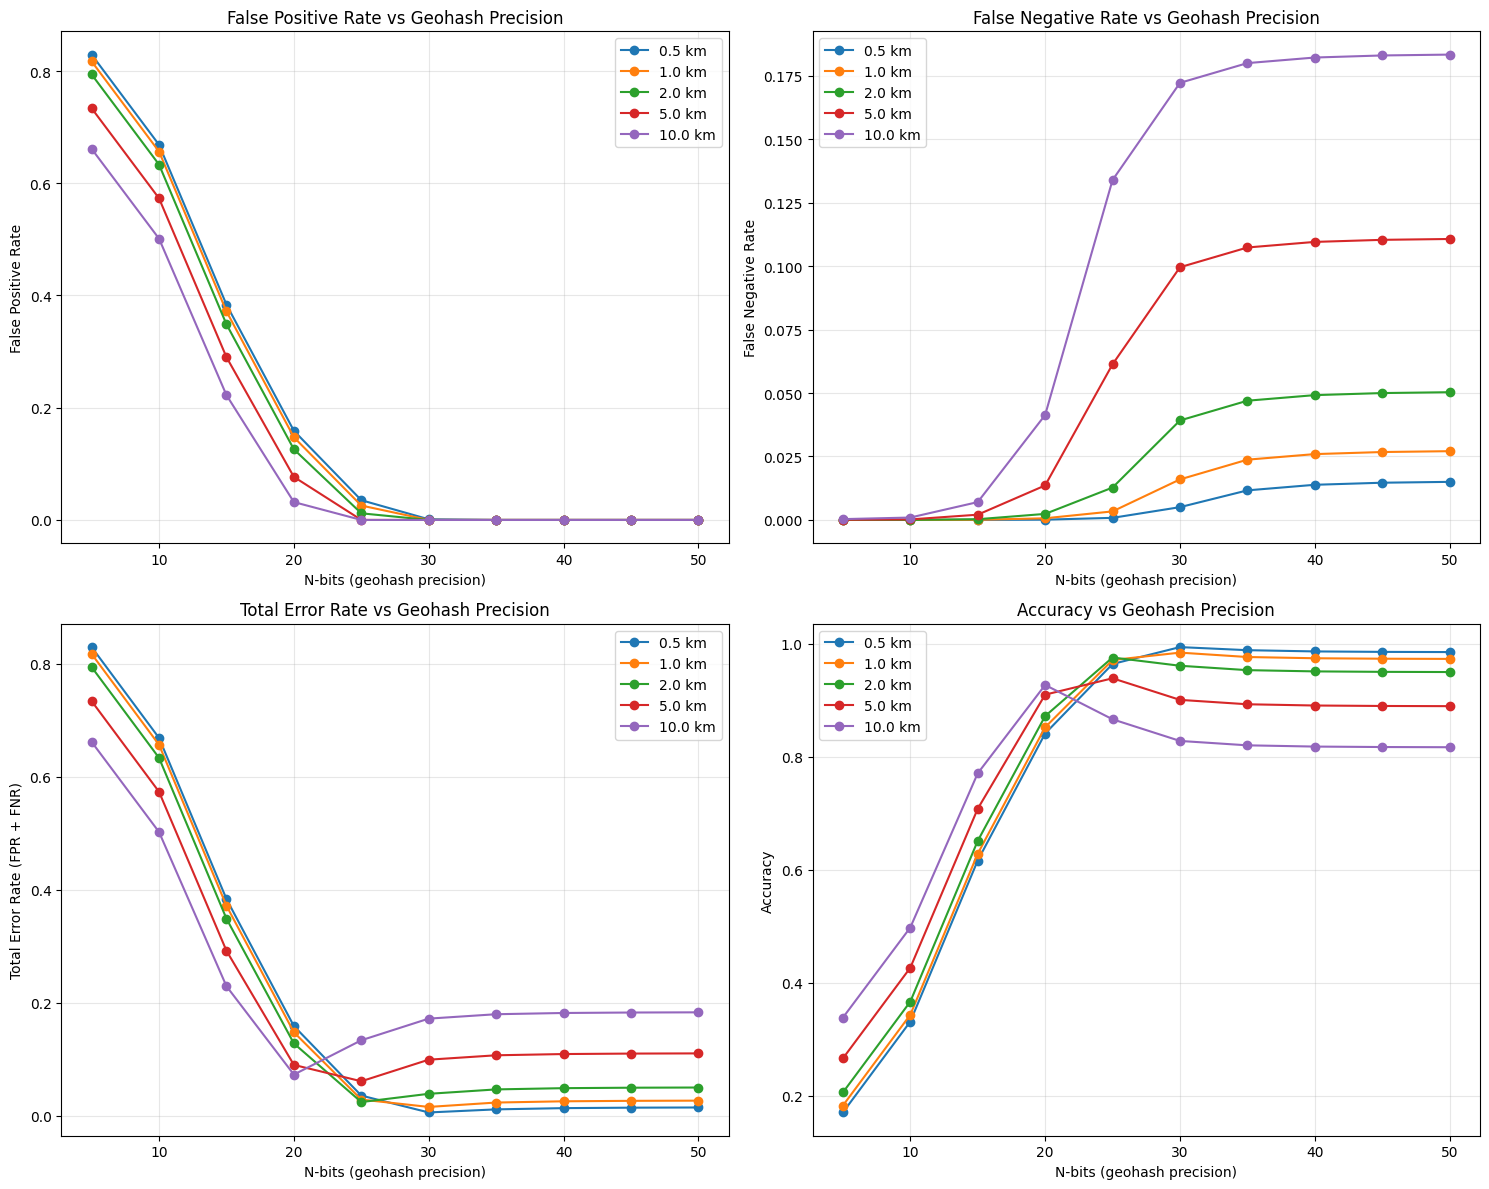

In [29]:
from matplotlib import pyplot as plt

# Visualize error rates
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: False Positive Rate vs N-bits for different thresholds
ax1 = axes[0, 0]
for threshold_km in distance_thresholds_km:
    n_bits_sorted = sorted(n_bits_list)
    fpr = [all_results[threshold_km][n]['false_positive_rate'] for n in n_bits_sorted]
    ax1.plot(n_bits_sorted, fpr, marker='o', label=f'{threshold_km} km')
ax1.set_xlabel('N-bits (geohash precision)')
ax1.set_ylabel('False Positive Rate')
ax1.set_title('False Positive Rate vs Geohash Precision')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: False Negative Rate vs N-bits for different thresholds
ax2 = axes[0, 1]
for threshold_km in distance_thresholds_km:
    n_bits_sorted = sorted(n_bits_list)
    fnr = [all_results[threshold_km][n]['false_negative_rate'] for n in n_bits_sorted]
    ax2.plot(n_bits_sorted, fnr, marker='o', label=f'{threshold_km} km')
ax2.set_xlabel('N-bits (geohash precision)')
ax2.set_ylabel('False Negative Rate')
ax2.set_title('False Negative Rate vs Geohash Precision')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Total Error Rate (FPR + FNR) vs N-bits
ax3 = axes[1, 0]
for threshold_km in distance_thresholds_km:
    n_bits_sorted = sorted(n_bits_list)
    total_error = [all_results[threshold_km][n]['false_positive_rate'] + 
                   all_results[threshold_km][n]['false_negative_rate'] for n in n_bits_sorted]
    ax3.plot(n_bits_sorted, total_error, marker='o', label=f'{threshold_km} km')
ax3.set_xlabel('N-bits (geohash precision)')
ax3.set_ylabel('Total Error Rate (FPR + FNR)')
ax3.set_title('Total Error Rate vs Geohash Precision')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Accuracy vs N-bits
ax4 = axes[1, 1]
for threshold_km in distance_thresholds_km:
    n_bits_sorted = sorted(n_bits_list)
    accuracy = [all_results[threshold_km][n]['accuracy'] for n in n_bits_sorted]
    ax4.plot(n_bits_sorted, accuracy, marker='o', label=f'{threshold_km} km')
ax4.set_xlabel('N-bits (geohash precision)')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy vs Geohash Precision')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
